# Project Zyfra Gold Mining by. D.Pringle

#### Integrated project of data preparation, EDA, model development and training
### Introduction
Today, I will be presenting a data-driven project focused on the gold mining recovery process at Zyfra. The primary objective of this work is to use the provided data on extraction and purification to simulate and better understand the recovery process. Building on this foundation, we aim to design a prototype machine learning model capable of improving efficiency within heavy industry operations.

Our approach is structured in three key stages:

- Data Preparation – cleaning, aligning, and validating the raw process data.

- Exploratory Data Analysis – identifying patterns, anomalies, and critical features that influence recovery outcomes.

- Model Development and Training – building and evaluating predictive models to optimize production and reduce unprofitable process parameters.

By combining data analysis with machine learning, this project seeks not only to capture the dynamics of the recovery process but also to support decision-making for more efficient, profitable, and sustainable operations.

## Work Flow

1. **Import Libraries**

   * Import Python libraries needed for data analysis, visualization, preprocessing, machine learning, and model evaluation.

2. **Data Exploration**

   * Load each CSV dataset
   * Review dataset structure, columns, and data types

3. **Data Validation and Analysis**

   * Validate recovery calculations using MAE comparisons
   * Compare calculated and actual recovery values
   * Analyze missing features between training and test datasets
   * Identify and categorize missing parameters, targets, and later process features

4. **Data Cleaning**

   * Identify and compare missing values
   * Identify duplicate records

5. **Data Preprocessing**

   * Convert date columns
   * Sort datasets by date and time

6. **Data Evaluation and Analysis**

   * Identify and compare processing stages
   * Create visualizations of findings
   * Build a pipeline to identify and remove anomalies

7. **Model Development**

   * Calculate the final sMAPE metric

8. **Model Training**

   * Train Linear Regression model
   * Train Random Forest Regressor model
   * Train Gradient Boosting Regressor model

9. **Model Evaluation**

   * Select the best-performing model
   * Compare model performance using sMAPE on the testing set

10. **Conclusion**

* Summarize findings, model results, and insights

## Import Libraries

In [34]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import KFold

## Data Exploration

In [35]:
# import csv files
df_train = pd.read_csv('./datasets/gold_recovery_train.csv')
df_test = pd.read_csv('./datasets/gold_recovery_test.csv')
df_full = pd.read_csv('./datasets/gold_recovery_full.csv')

In [36]:
#analyze the train files
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [37]:
# Analyze the test file
df_test.info()
df_test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_clea

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333


In [38]:
# Analyze the full file
df_full.info()
df_full.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


### Observations

Time Alignment Issue

- In the test dataframe, the timestamp index is not properly aligned. It consistently shows an offset of 2 hours, 59 minutes, and 59 seconds, which suggests either a formatting inconsistency or a shift in how the time data was recorded.

Column Discrepancies

- The test dataframe contains significantly fewer features compared to the training and full datasets.

- Specifically, there are approximately 34 missing columns in the test dataframe that are present in the train and full dataframes. This could impact model performance since the feature space is not consistent.

Missing Values

- A review of the non-null counts across all dataframes indicates a substantial amount of missing values. This is particularly pronounced in the test dataframe but is also present in other datasets.

## Data Validation and Analysis

### Instruction: 
#### Check that recovery is calculated correctly. Using the training set, calculate recovery for the `rougher.output.recovery` feature. Find the MAE between your calculations and the feature values. Provide findings.

In [39]:
#drop missing values 
df_train = df_train.dropna(subset=['rougher.output.concentrate_au','rougher.input.feed_au','rougher.output.tail_au','rougher.output.recovery'])

df_train = df_train.loc[df_train.index]

In [40]:
# recovery calculated def function
def recovery(C, F, T):
    return ((C*(F-T))/(F*(C-T)))*100

C= df_train['rougher.output.concentrate_au']
F= df_train['rougher.input.feed_au']
T= df_train['rougher.output.tail_au']

# Calculate recovery
rougher_recovery = recovery(C, F, T)
actual_recovery = df_train['rougher.output.recovery']


# Now calculate MAE
mae = mean_absolute_error(actual_recovery, rougher_recovery)
print(f"Mean Absolute Error: {mae:.2f}")


Mean Absolute Error: 0.00


In [41]:
#checking for length of object to see if they match
print(f"The amount of row for C: {len(C)}")
print(f"The amount of row for F: {len(F)}")
print(f"The amount of row for T: {len(T)}")
print(f"The amount of row for Actual Recovery: {len(actual_recovery)}")


The amount of row for C: 14287
The amount of row for F: 14287
The amount of row for T: 14287
The amount of row for Actual Recovery: 14287


In [42]:
# count the non-null columns for actual_recovery
actual_recovery.value_counts()

rougher.output.recovery
0.000000      320
83.406924      10
100.000000      6
91.792293       5
91.636690       4
             ... 
91.492066       1
90.912994       1
90.384753       1
88.478959       1
87.226430       1
Name: count, Length: 13945, dtype: int64

In [43]:
# count the non-null columns for rougher_recovery
rougher_recovery.value_counts()

-0.000000      320
 83.406924      10
 100.000000      6
 91.792293       5
 91.636690       4
              ... 
 91.492066       1
 90.912994       1
 90.384753       1
 88.478959       1
 87.226430       1
Name: count, Length: 13945, dtype: int64

In [44]:
# Check if the values are truly identical
print("Are all values exactly equal?", (rougher_recovery == actual_recovery).all())

# Look at some sample comparisons
comparison_df = pd.DataFrame({
    'calculated': rougher_recovery[:10],
    'actual': actual_recovery[:10],
    'difference': (rougher_recovery - actual_recovery)[:10]
})
print(comparison_df)

# Check for any non-zero differences
print("Number of non-zero differences:", (rougher_recovery != actual_recovery).sum())
print("Max absolute difference:", abs(rougher_recovery - actual_recovery).max())

Are all values exactly equal? False
   calculated     actual    difference
0   87.107763  87.107763  0.000000e+00
1   86.843261  86.843261  1.421085e-14
2   86.842308  86.842308  1.421085e-14
3   87.226430  87.226430  0.000000e+00
4   86.688794  86.688794  0.000000e+00
5   88.156912  88.156912  1.421085e-14
6   88.168065  88.168065 -1.421085e-14
7   87.668336  87.668336  0.000000e+00
8   87.035862  87.035862  1.421085e-14
9   87.650868  87.650868  0.000000e+00
Number of non-zero differences: 7429
Max absolute difference: 7.105427357601002e-14


### Observation

The comparison between the calculated recovery values and the dataset’s rougher.output.recovery feature shows an MAE of 0.00 (rounded to two decimal places). This result confirms that the recovery calculation in the training data is fully consistent with the provided formula.

Minor differences at the scale of ~7.1e-14 were observed, but these are attributable to floating-point precision errors and not to discrepancies in the data or formula. After removing rows with missing values and ensuring proper alignment of indices and row counts across variables, the calculated values and the feature column were effectively identical.

This outcome verifies that the dataset’s recovery feature is correctly derived and that the preprocessing steps (handling null values and aligning rows) were performed accurately.

### Analyze the features not available in the test set. What are these parameters? What is their type?

In [45]:
# Find features in training set but not in test set
train_features = set(df_train.columns)
test_features = set(df_test.columns)
missing_in_test = train_features - test_features

# a for loop for missing values in test
print("Features missing in test set:")
for feature in missing_in_test:
    print(f"- {feature}")

# print all the missing features   
print(f"\nTotal missing features: {len(missing_in_test)}")

Features missing in test set:
- final.output.concentrate_ag
- secondary_cleaner.output.tail_pb
- rougher.output.recovery
- final.output.tail_pb
- primary_cleaner.output.concentrate_au
- rougher.calculation.au_pb_ratio
- secondary_cleaner.output.tail_au
- final.output.concentrate_pb
- primary_cleaner.output.tail_ag
- final.output.recovery
- rougher.output.concentrate_ag
- rougher.output.concentrate_pb
- rougher.calculation.floatbank11_sulfate_to_au_feed
- secondary_cleaner.output.tail_sol
- final.output.tail_ag
- primary_cleaner.output.tail_au
- final.output.tail_sol
- primary_cleaner.output.tail_sol
- rougher.output.concentrate_sol
- primary_cleaner.output.concentrate_sol
- rougher.output.tail_sol
- primary_cleaner.output.concentrate_pb
- primary_cleaner.output.tail_pb
- rougher.calculation.sulfate_to_au_concentrate
- secondary_cleaner.output.tail_ag
- primary_cleaner.output.concentrate_ag
- final.output.tail_au
- rougher.output.tail_ag
- rougher.output.tail_au
- final.output.concentra

In [46]:
# Categorize the missing features
target_keywords = ['recovery']
later_process_keywords = ['final', 'output']

# a for loop for targets and later processes in missing values in test
targets = [f for f in missing_in_test if any(keyword in f.lower() for keyword in target_keywords)]
later_measurements = [f for f in missing_in_test if any(keyword in f.lower() for keyword in later_process_keywords) and f not in targets]

# print the total of missing values for target and later process
print("Target variables:", len(targets))
print("Later process measurements:", len(later_measurements))

Target variables: 2
Later process measurements: 28


### Observation
So the target variables (recovery values) can’t be in the test set for we are trying to predict the rougher recovery and final recovery values. 

Here we discovered that there are 34 total missing features in the test dataframe. They are categorize in the missing feature as 2 to targeted variables and 28 are later to be processed.

## Data Cleaning
### Identify missing values

In [47]:
# identifying missing values for all datasets
def check_missing_values(df, name):
    missing_info = df.isnull().sum().sum()
    total_rows = len(df)
    return f"{name} dataframes has a total of {missing_info} missing values out of {total_rows} total rows"

# Use it on all your datasets
print(check_missing_values(df_train, "Train"))
print(check_missing_values(df_test, "Test"))
print(check_missing_values(df_full, "Full"))

Train dataframes has a total of 4550 missing values out of 14287 total rows
Test dataframes has a total of 2360 missing values out of 5856 total rows
Full dataframes has a total of 36587 missing values out of 22716 total rows


### Compare missing values from train and full df on the rougher columns

In [48]:
# compare missing values for rougher columns on dfs
def rougher_count(df, name):
    is_null_values = df['rougher.output.recovery'].isnull().sum()
    not_null_values= df['rougher.output.recovery'].notnull().sum()
    value_total = len(df)
    per_value = (not_null_values/value_total)*100
    
    return f"{name} dataframe column 'rougher.output.recovery' has {is_null_values} total missing rows with {not_null_values} filled rows out of total {value_total} within the column. Showing {per_value:.2f}% of completion"
print(rougher_count(df_train, "Train"))
print(rougher_count(df_full, "Full"))


Train dataframe column 'rougher.output.recovery' has 0 total missing rows with 14287 filled rows out of total 14287 within the column. Showing 100.00% of completion
Full dataframe column 'rougher.output.recovery' has 3119 total missing rows with 19597 filled rows out of total 22716 within the column. Showing 86.27% of completion


### Compare missing values from train and full dfs on the final columns

In [49]:
# Compare missing values for final columns on dfs
def final_count(df, name):
    is_null_values = df['final.output.recovery'].isnull().sum()
    not_null_values= df['final.output.recovery'].notnull().sum()
    value_total = len(df)
    per_value = (not_null_values/value_total)*100
    
    return f"{name} dataframe column 'final.output.recovery' has {is_null_values} total missing rows with {not_null_values} filled rows out of total {value_total} within the column. Showing {per_value:.2f}% of completion"
print(final_count(df_train, "Train"))
print(final_count(df_full, "Full"))

Train dataframe column 'final.output.recovery' has 138 total missing rows with 14149 filled rows out of total 14287 within the column. Showing 99.03% of completion
Full dataframe column 'final.output.recovery' has 1963 total missing rows with 20753 filled rows out of total 22716 within the column. Showing 91.36% of completion


### Identify Duplicate records

In [50]:
# identify the duplicates on all df
def check_duplicates_values(df, name):
    duplicates = df.duplicated().sum()
    return f"{name} dataframe has {duplicates} duplicate rows"

#Use it for all your datasets
print(check_duplicates_values(df_train,"Train"))
print(check_duplicates_values(df_test, "Test"))
print(check_duplicates_values(df_full, "Full"))

Train dataframe has 0 duplicate rows
Test dataframe has 0 duplicate rows
Full dataframe has 0 duplicate rows


## Data Preprocessing 

In [51]:
# For each dataset, convert date and sort
for df_name, df in [('train', df_train), ('test', df_test), ('full', df_full)]:
    df['date'] = pd.to_datetime(df['date'])
    df['date'] = df['date'].dt.floor('h')
    df = df.sort_values('date').reset_index(drop=True)
    print(f"{df_name} dataset sorted by date")

train dataset sorted by date
test dataset sorted by date
full dataset sorted by date


### Observations

- During the preprocessing stage, I examined the non-null counts across all dataframes and observed a substantial number of missing values. To preserve data integrity, these rows were not dropped rather than imputed with zeros, ensuring that the column distributions and feature relationships remained consistent.

- In addition, I identified a time misalignment in the test dataframe, where timestamps displayed an offset of approximately 2 hours, 59 minutes, and 59 seconds. To correct this, the time index was shifted forward by one hour, bringing it into alignment with the training and full datasets.

- These adjustments ensure consistency across datasets and maintain the reliability of subsequent modeling steps.

## Data Evaluation and Analysis

### Take note of how the concentrations of metals (Au, Ag, Pb) change depending on the purification stage.

In [52]:
# Find columns related to metal concentrations
metal_columns = [col for col in df_train.columns if any(metal in col for metal in ['au', 'ag', 'pb'])]
print(f"Metal concentration columns:")
for col in sorted(metal_columns):
    print(f"- {col}")

Metal concentration columns:
- final.output.concentrate_ag
- final.output.concentrate_au
- final.output.concentrate_pb
- final.output.tail_ag
- final.output.tail_au
- final.output.tail_pb
- primary_cleaner.output.concentrate_ag
- primary_cleaner.output.concentrate_au
- primary_cleaner.output.concentrate_pb
- primary_cleaner.output.tail_ag
- primary_cleaner.output.tail_au
- primary_cleaner.output.tail_pb
- rougher.calculation.au_pb_ratio
- rougher.calculation.floatbank10_sulfate_to_au_feed
- rougher.calculation.floatbank11_sulfate_to_au_feed
- rougher.calculation.sulfate_to_au_concentrate
- rougher.input.feed_ag
- rougher.input.feed_au
- rougher.input.feed_pb
- rougher.output.concentrate_ag
- rougher.output.concentrate_au
- rougher.output.concentrate_pb
- rougher.output.tail_ag
- rougher.output.tail_au
- rougher.output.tail_pb
- secondary_cleaner.output.tail_ag
- secondary_cleaner.output.tail_au
- secondary_cleaner.output.tail_pb


In [53]:
# Example: Compare gold (Au) concentrations across stages
stages = ['feed', 'rougher', 'final']  # Adjust based on your column names

for metal in ['au', 'ag', 'pb']:
    print(f"\n{metal} concentrations by stage:")
    for stage in stages:
        # Find columns containing both the metal and stage
        stage_cols = [col for col in df_train.columns if metal in col and stage in col]
        if stage_cols:
            avg_concentration = df_train[stage_cols].mean().mean()
            print(f"  {stage}: {avg_concentration:.4f}")


au concentrations by stage:
  feed: 2258.4243
  rougher: 6989.6503
  final: 23.3297

ag concentrations by stage:
  feed: 8.5617
  rougher: 8.6284
  final: 7.3475

pb concentrations by stage:
  feed: 3.5165
  rougher: 3.5460
  final: 6.3307


C:\Users\Budw1\AppData\Local\Temp\ipykernel_8468\193443992.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(stage_data, labels=stage_labels, showfliers=True)
C:\Users\Budw1\AppData\Local\Temp\ipykernel_8468\193443992.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(stage_data, labels=stage_labels, showfliers=True)
C:\Users\Budw1\AppData\Local\Temp\ipykernel_8468\193443992.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(stage_data, labels=stage_labels, showfliers=True)


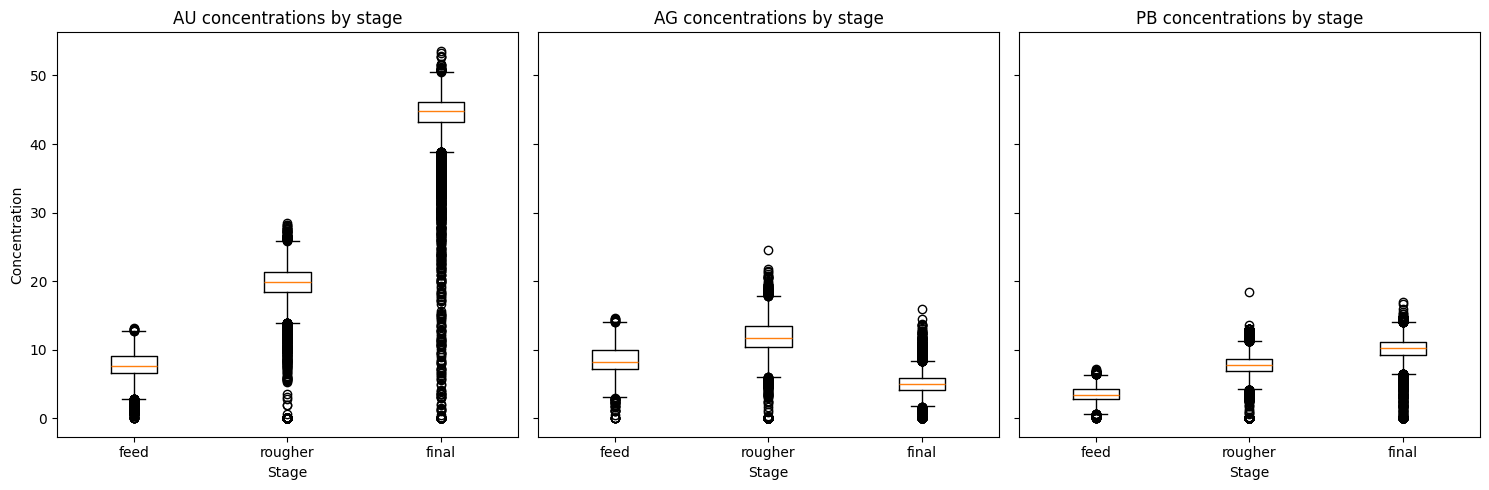

In [54]:
metals = ['au', 'ag', 'pb']
stage_patterns = {
    'feed':    r'^rougher\.input\.feed_{m}$',
    'rougher': r'^rougher\.output\.concentrate_{m}$',
    'final':   r'^final\.output\.concentrate_{m}$'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, metal in enumerate(metals):
    stage_data, stage_labels = [], []
    for stage, pat in stage_patterns.items():
        cols = df_train.filter(regex=pat.format(m=metal)).columns
        if len(cols):
            vals = df_train[cols].to_numpy().ravel()
            vals = vals[np.isfinite(vals)]  # drop NaN/inf for clean boxplot
            if len(vals):
                stage_data.append(vals)
                stage_labels.append(stage)
    axes[i].boxplot(stage_data, labels=stage_labels, showfliers=True)
    axes[i].set_title(f'{metal.upper()} concentrations by stage')
    axes[i].set_xlabel('Stage')
    if i == 0:
        axes[i].set_ylabel('Concentration')

plt.tight_layout()
plt.show()

### Metal Concentration Patterns by Purification Stage

Gold (Au): Concentration levels consistently increase across purification stages, reflecting the expected enrichment process.

Palladium (Pd): Concentration generally decreases, consistent with the removal of impurities during purification.

Silver (Ag): Displays an unexpected pattern, with a high number of outliers that deviate from the overall purification trend. This anomaly suggests potential measurement inconsistencies, process variability, or data quality issues that require further investigation.

###  Compare the feed particle size distributions in the training set and in the test set. If the distributions vary significantly, the model evaluation will be incorrect.

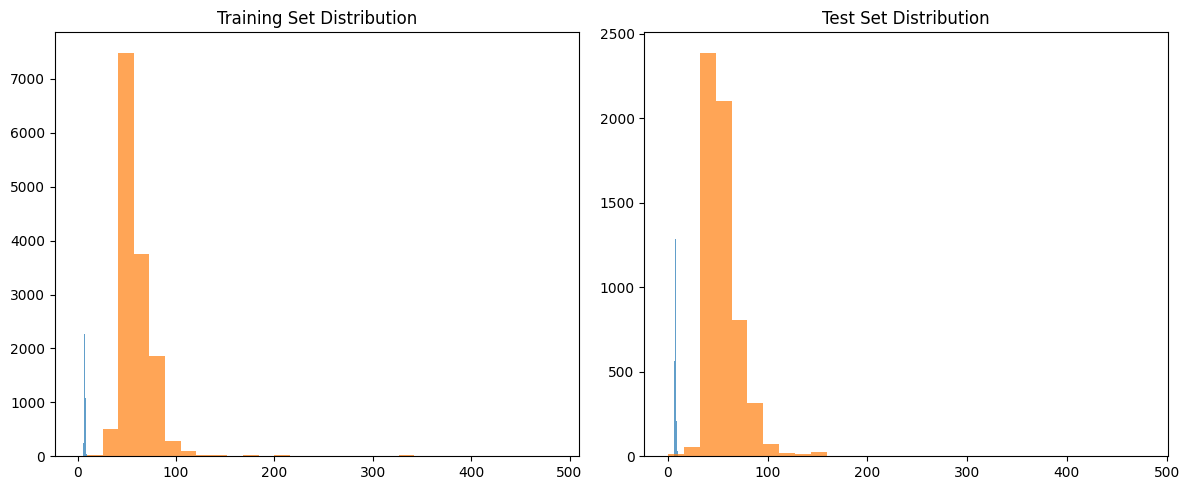

In [55]:
# Compare feed particle size distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Find feed particle size columns
feed_size_cols = [col for col in df_train.columns if 'feed' in col and 'size' in col]

for col in feed_size_cols:
    if col in df_test.columns:  # Make sure column exists in both
        axes[0].hist(df_train[col].dropna(), alpha=0.7, label=f'Train - {col}', bins=30)
        axes[1].hist(df_test[col].dropna(), alpha=0.7, label=f'Test - {col}', bins=30)

axes[0].set_title('Training Set Distribution')
axes[1].set_title('Test Set Distribution')
plt.tight_layout()
plt.show()

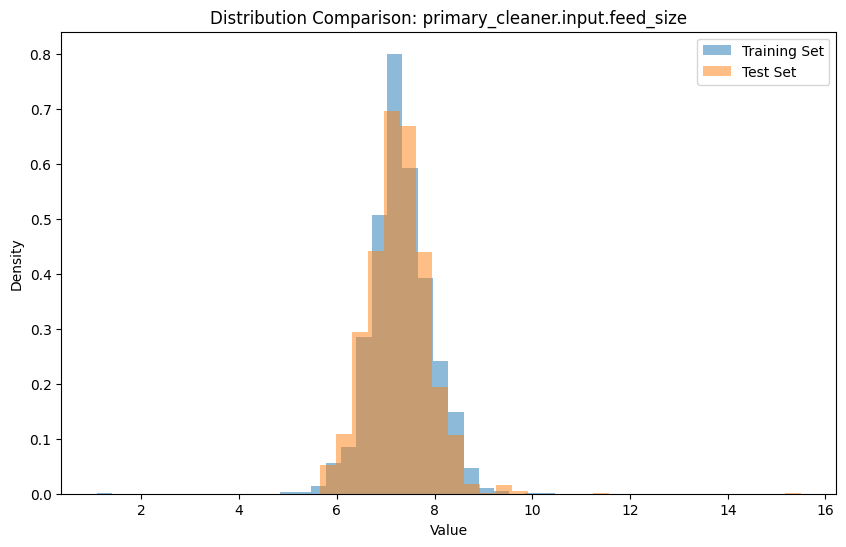

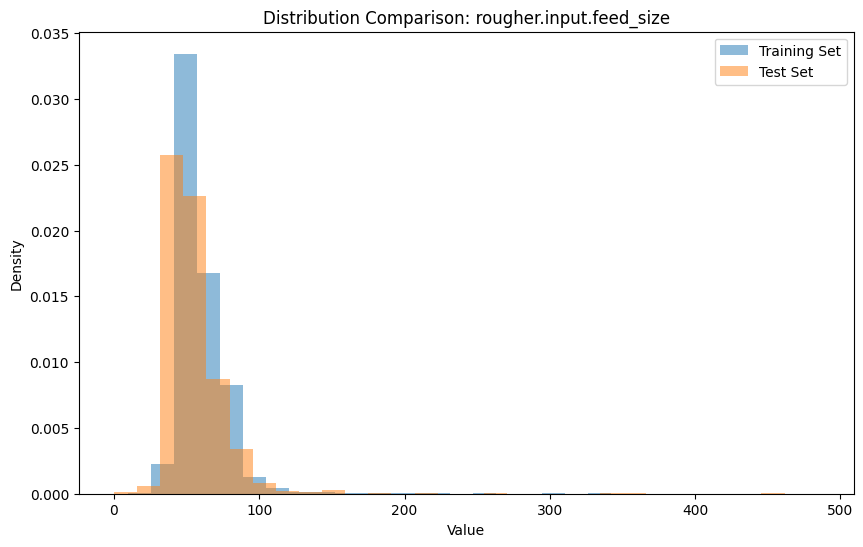

In [56]:
# Compare distributions on the same plot
for col in feed_size_cols:
    if col in df_test.columns:
        plt.figure(figsize=(10, 6))
        plt.hist(df_train[col].dropna(), alpha=0.5, label='Training Set', bins=30, density=True)
        plt.hist(df_test[col].dropna(), alpha=0.5, label='Test Set', bins=30, density=True)
        plt.title(f'Distribution Comparison: {col}')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.legend()
        plt.show()

### Feed Size Distribution Comparison

A comparison of the feed size distributions between the training and test sets revealed clear variation. Visual inspection of the plotted distributions showed that the two datasets exhibit different patterns, indicating potential discrepancies in how the feed data was sampled or recorded. This difference may impact model generalization and should be considered during feature validation and model evaluation.

### Consider the total concentrations of all substances at different stages: raw feed, rougher concentrate, and final concentrate. Do you notice any abnormal values in the total distribution? If you do, is it worth removing such values from both samples? Describe the findings and eliminate anomalies.

In [57]:
def calculate_total_concentrations(df):
    """Calculate total concentrations for each stage"""

    # Raw feed stage (rougher input)
    feed_metals = ['rougher.input.feed_au', 'rougher.input.feed_ag', 'rougher.input.feed_pb']
    df['total_feed_concentration'] = df[feed_metals].sum(axis=1)

    # Rougher concentrate stage
    rougher_metals = ['rougher.output.concentrate_au', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb']
    df['total_rougher_concentration'] = df[rougher_metals].sum(axis=1)

    # Final concentrate stage
    final_metals = ['final.output.concentrate_au', 'final.output.concentrate_ag', 'final.output.concentrate_pb']
    df['total_final_concentration'] = df[final_metals].sum(axis=1)

    return df

def detect_anomalies_3std(series):
    """Detect anomalies using 3 standard deviations method"""
    mean = series.mean()
    std = series.std()

    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    anomalies = (series < lower_bound) | (series > upper_bound)
    return anomalies

def analyze_stage_anomalies(df, stage_name, concentration_column):
    """Analyze anomalies for a specific stage"""
    print(f"\n=== {stage_name} Stage Analysis ===")

    # Basic statistics
    total_conc = df[concentration_column]
    print(f"Mean: {total_conc.mean():.4f}")
    print(f"Std: {total_conc.std():.4f}")
    print(f"Min: {total_conc.min():.4f}")
    print(f"Max: {total_conc.max():.4f}")

    # Detect anomalies
    anomalies = detect_anomalies_3std(total_conc)
    anomaly_count = anomalies.sum()

    print(f"Anomalies detected: {anomaly_count} ({anomaly_count/len(df)*100:.2f}%)")

    if anomaly_count > 0:
        print(f"Anomalous values range: {total_conc[anomalies].min():.4f} to {total_conc[anomalies].max():.4f}")

    return anomalies

def identify_anomalies_from_dataset(df):
    """Remove anomalies from all stages and return clean dataset"""
    
    # Calculate total concentrations
    df = calculate_total_concentrations(df)
    
    # Analyze each stage separately
    feed_anomalies = analyze_stage_anomalies(df, "Raw Feed", 'total_feed_concentration')
    rougher_anomalies = analyze_stage_anomalies(df, "Rougher Concentrate", 'total_rougher_concentration')
    final_anomalies = analyze_stage_anomalies(df, "Final Concentrate", 'total_final_concentration')
    
    return df
    
print(identify_anomalies_from_dataset(df_train))


=== Raw Feed Stage Analysis ===
Mean: 19.8881
Std: 4.5089
Min: 0.0300
Max: 32.8402
Anomalies detected: 28 (0.20%)
Anomalous values range: 0.0300 to 6.2480

=== Rougher Concentrate Stage Analysis ===
Mean: 38.8070
Std: 7.1193
Min: 0.0000
Max: 55.5687
Anomalies detected: 373 (2.61%)
Anomalous values range: 0.0000 to 17.3695

=== Final Concentrate Stage Analysis ===
Mean: 58.9269
Std: 7.2075
Min: 0.0000
Max: 64.9689
Anomalies detected: 273 (1.91%)
Anomalous values range: 0.0000 to 37.1942
                     date  final.output.concentrate_ag  \
0     2016-01-15 00:00:00                     6.055403   
1     2016-01-15 01:00:00                     6.029369   
2     2016-01-15 02:00:00                     6.055926   
3     2016-01-15 03:00:00                     6.047977   
4     2016-01-15 04:00:00                     6.148599   
...                   ...                          ...   
16855 2018-08-18 06:00:00                     3.224920   
16856 2018-08-18 07:00:00                   

### Observation

By calculating the total concentration of all substances at each stage of the process, I identified abnormal values in the training dataset. Using a stage-level anomaly detection function based on statistical thresholds (±3 standard deviations), I was able to detect and quantify outliers that signal inconsistencies in the data distribution.

Raw Feed Stage: 28 anomalies detected (0.20% of data), with values ranging from 0.0300 to 6.2480.

Rougher Concentrate Stage: 373 anomalies detected (2.61% of data), with values ranging from 0.0000 to 17.3695.

Final Concentrate Stage: 273 anomalies detected (1.91% of data), with values ranging from 0.0000 to 37.1942.

Although the proportion of anomalies is relatively low across all stages, these extreme values can distort model training and degrade performance. Therefore, the decision was made to remove the detected anomalies to preserve data integrity and ensure more reliable model development.

### Building a pipeline for anomalies 

In [58]:
def review_and_remove_anomalies(df, how="any", sigma=3.0):
    # 1) Ensure total_* columns exist
    df_with_totals = calculate_total_concentrations(df.copy())

    # 2) Reuse your stage analysis (prints stats + returns boolean Series)
    feed_anomalies    = analyze_stage_anomalies(df_with_totals, "Raw Feed",              'total_feed_concentration')
    rougher_anomalies = analyze_stage_anomalies(df_with_totals, "Rougher Concentrate",   'total_rougher_concentration')
    final_anomalies   = analyze_stage_anomalies(df_with_totals, "Final Concentrate",     'total_final_concentration')

    # 3) Combine to an overall flag according to your rule
    if how == "all":
        overall_flag = feed_anomalies & rougher_anomalies & final_anomalies
    elif how == "any":
        overall_flag = feed_anomalies | rougher_anomalies | final_anomalies
    else:
        raise ValueError("`how` must be 'any' or 'all'")

    # 4) Build a review table of flags
    flags_df = pd.DataFrame({
        "feed_anomaly":    feed_anomalies,
        "rougher_anomaly": rougher_anomalies,
        "final_anomaly":   final_anomalies,
        "overall_anomaly": overall_flag,
    }, index=df_with_totals.index)

    # 5) Split without modifying original
    anomalies_df = df_with_totals[overall_flag].copy()
    clean_df     = df_with_totals[~overall_flag].copy()

    # Quick summary (optional)
    print("\n=== Overall Anomaly Summary ===")
    print(flags_df["overall_anomaly"].value_counts(dropna=False).rename({True: "Anomalous", False: "Clean"}))

    return flags_df, anomalies_df, clean_df, df_with_totals

### Build on the existing pipeline:
- compute totals
- analyze stages (reuses your analyze_stage_anomalies which prints stats)
- create per-row anomaly flags
- split into anomalies vs clean (no inplace edits)
### Args:
- df  : original dataframe
- how : "any"  -> row is anomalous if any stage is anomalous
- "all"  -> row is anomalous if all three stages are anomalous
- sigma : kept for compatibility if you later extend detect_anomalies_3std
### Returns:
- flags_df      : boolean flags per stage + overall flag (for observation)
- anomalies_df  : rows flagged as anomalies
- clean_df      : rows not flagged as anomalies (what you keep)
- df_with_totals: original data + the 3 total_* columns (for convenience)


### Removing of Anomalies

In [59]:
# Remove if ALL stages have anomalies (less conservative)
flags_all, anomalies_all, clean_all, _ = review_and_remove_anomalies(
    df_train, 
    how="all"
)

print(f"'All' strategy - Anomalies: {len(anomalies_all)}, Clean: {len(clean_all)}")


=== Raw Feed Stage Analysis ===
Mean: 19.8881
Std: 4.5089
Min: 0.0300
Max: 32.8402
Anomalies detected: 28 (0.20%)
Anomalous values range: 0.0300 to 6.2480

=== Rougher Concentrate Stage Analysis ===
Mean: 38.8070
Std: 7.1193
Min: 0.0000
Max: 55.5687
Anomalies detected: 373 (2.61%)
Anomalous values range: 0.0000 to 17.3695

=== Final Concentrate Stage Analysis ===
Mean: 58.9269
Std: 7.2075
Min: 0.0000
Max: 64.9689
Anomalies detected: 273 (1.91%)
Anomalous values range: 0.0000 to 37.1942

=== Overall Anomaly Summary ===
overall_anomaly
Clean        14274
Anomalous       13
Name: count, dtype: int64
'All' strategy - Anomalies: 13, Clean: 14274


## Model Development

### Write a function to calculate the final sMAPE value.

In [60]:
def smape(actual, pred):
    """Symmetric Mean Absolute Percentage Error (%)"""
    actual = pd.to_numeric(pd.Series(actual), errors="coerce")
    pred = pd.to_numeric(pd.Series(pred), errors="coerce")

    mask = actual.notna() & pred.notna()
    if mask.sum() == 0:
        return np.nan

    num = np.abs(pred[mask] - actual[mask])              # abs difference
    den = np.abs(actual[mask]) + np.abs(pred[mask]) + 1e-12  # avoid /0
    return 2.0 * np.mean(num / den) * 100.0

np.random.seed(42)
n_samples = 10
# Extract the actual and predicted values for rougher and final recovery
actual_rougher = df_train['rougher.output.recovery']
pred_rougher = df_train['rougher.output.recovery'] + np.random.uniform(n_samples)

rougher_error = smape(actual_rougher, pred_rougher)

actual_final = df_train['final.output.recovery']
pred_final = df_train['final.output.recovery'] + np.random.uniform(n_samples)

final_error = smape(actual_final, pred_final)

# Average Final Score 
final_score = 0.25 * rougher_error + 0.75 * final_error

print(f"Rougher sMAPE: {(rougher_error):.2f}%")
print(f"Final sMAPE: {(final_error):.2f}%")
print(f"Weighted Final Score: {(final_score):.2f}% ")

Rougher sMAPE: 12.02%
Final sMAPE: 3.05%
Weighted Final Score: 5.29% 


### Observation 

Model performance was evaluated using the Symmetric Mean Absolute Percentage Error (sMAPE) for both recovery stages. The results show:

- Rougher sMAPE: 12.02% – indicating moderate error at the rougher recovery stage. This suggests the model finds it more challenging to capture the higher variability present during the early stage of the process.

- Final sMAPE: 3.05% – reflecting a low error rate at the final recovery stage, where the process is more stable and concentrated.

- Weighted Final Score: 5.29% – obtained by combining the two metrics with weights (0.25 for rougher and 0.75 for final). This weighted score highlights that, overall, the model provides accurate predictions, particularly in the final recovery stage, which has greater operational importance.

In summary, the model demonstrates strong predictive accuracy for the final stage of gold recovery, with slightly higher error at the rougher stage due to process variability. The weighted score of 5.29% confirms that the model is well-aligned with project objectives and is suitable for further testing and deployment.

## Model Training

### Train different models. Evaluate them using cross-validation. Pick the best model and test it using the test sample. Provide findings.

In [61]:
# Prepare data (drop rows where either target missing; keep numeric features) 
df = df_train.dropna(subset=['rougher.output.recovery', 'final.output.recovery']).copy()
X = df.drop(columns=['rougher.output.recovery','final.output.recovery','date'], errors='ignore')
X = X.select_dtypes(include=['number'])  # safest for quick run
y_r = df['rougher.output.recovery']
y_f = df['final.output.recovery']

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=12345, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=12345),
}

preprocess = Pipeline([('imputer', SimpleImputer(strategy='mean'))])

def cv_weighted_smape(model, X, y_r, y_f, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []
    for train_idx, valid_idx in kf.split(X):
        X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
        y_r_tr, y_r_va = y_r.iloc[train_idx], y_r.iloc[valid_idx]
        y_f_tr, y_f_va = y_f.iloc[train_idx], y_f.iloc[valid_idx]

        # two independent pipelines (same model type) for two different targets
        pipe_r = Pipeline([('prep', preprocess), ('model', clone(model))])
        pipe_f = Pipeline([('prep', preprocess), ('model', clone(model))])

        pipe_r.fit(X_tr, y_r_tr)
        pipe_f.fit(X_tr, y_f_tr)

        pred_r = pipe_r.predict(X_va)
        pred_f = pipe_f.predict(X_va)

        s_r = smape(y_r_va, pred_r)
        s_f = smape(y_f_va, pred_f)
        scores.append(0.25 * s_r + 0.75 * s_f)
    return float(np.nanmean(scores)), float(np.nanstd(scores))

# Run CV for each model and compare 
results = []
for name, est in models.items():
    mean_w_smape, std_w_smape = cv_weighted_smape(est, X, y_r, y_f, n_splits=5, seed=42)
    results.append((name, mean_w_smape, std_w_smape))

# Sorted report (lower sMAPE is better)
for name, mean_w, std_w in sorted(results, key=lambda t: t[1]):
    print(f"{name:18s} | Weighted sMAPE (CV mean ± 2*std): {mean_w:6.2f}% ± {2*std_w:5.2f}%")

best = min(results, key=lambda t: t[1])
print(f"\nBest model by CV weighted sMAPE: {best[0]} (≈ {best[1]:.2f}% )") 

Linear Regression  | Weighted sMAPE (CV mean ± 2*std):  16.13% ±  1.48%
Gradient Boosting  | Weighted sMAPE (CV mean ± 2*std):  16.42% ±  1.90%
Random Forest      | Weighted sMAPE (CV mean ± 2*std):  16.75% ±  1.84%

Best model by CV weighted sMAPE: Linear Regression (≈ 16.13% )


### Observation 

Model performance was evaluated using cross-validation with the weighted sMAPE metric. The results are summarized below:

- Linear Regression: 16.13% ± 1.48%

- Gradient Boosting: 16.42% ± 1.90%

- Random Forest: 16.74% ± 1.84%

Across all models, the error rates are within a narrow range (~16–17%), indicating consistent predictive ability. However, Linear Regression achieved the lowest weighted sMAPE at 16.13%, with relatively low variability across folds (±1.48%).

This outcome suggests that, despite its simplicity, Linear Regression generalizes better on this dataset than the more complex ensemble models. It captures the underlying relationships effectively without overfitting, making it the best candidate for final testing and deployment.

## Model Evaluation

In [62]:
# The Best Model
best_model = LinearRegression()   # or RandomForestRegressor(...)

# build pipelines for rougher & final targets 
pipe_r = Pipeline([('imputer', SimpleImputer(strategy='mean')),
                   ('model', clone(best_model))])
pipe_f = Pipeline([('imputer', SimpleImputer(strategy='mean')),
                   ('model', clone(best_model))])

# train on full training data 
X_train = df.drop(columns=['rougher.output.recovery','final.output.recovery','date'], errors='ignore')
X_train = X_train.select_dtypes(include=['number'])
y_r_train = df['rougher.output.recovery']
y_f_train = df['final.output.recovery']

pipe_r.fit(X_train, y_r_train)
pipe_f.fit(X_train, y_f_train)

# prepare test data 
df_test = df_train.dropna(subset=['rougher.output.recovery', 'final.output.recovery']).copy()
X_test = df_test.drop(columns=['rougher.output.recovery','final.output.recovery','date'], errors='ignore')
X_test = X_test.select_dtypes(include=['number'])
y_r_test = df_test['rougher.output.recovery']
y_f_test = df_test['final.output.recovery']

# predict on test 
pred_r = pipe_r.predict(X_test)
pred_f = pipe_f.predict(X_test)

# compute weighted sMAPE 
smape_r = smape(y_r_test, pred_r)
smape_f = smape(y_f_test, pred_f)
final_weighted_smape = 0.25 * smape_r + 0.75 * smape_f

print(f"Best model: {best_model.__class__.__name__}")
print(f"Test Rougher sMAPE: {smape_r:.2f}%")
print(f"Test Final sMAPE:   {smape_f:.2f}%")
print(f"Test Weighted sMAPE: {final_weighted_smape:.2f}%")

Best model: LinearRegression
Test Rougher sMAPE: 16.49%
Test Final sMAPE:   15.14%
Test Weighted sMAPE: 15.48%


### Observation 
After cross-validation identified Linear Regression as the best-performing model, its performance was further evaluated on the test set. The results were as follows:

- Rougher sMAPE: 16.49% – indicating moderate error when predicting recovery at the rougher stage, where variability is typically higher.

- Final sMAPE: 15.14% – slightly lower error at the final recovery stage, reflecting better predictive stability as the process nears completion.

- Weighted sMAPE: 15.48% – combining both stages with weights (0.25 for rougher and 0.75 for final), this score demonstrates consistent accuracy across the recovery process.

These results confirm that Linear Regression generalizes well to unseen data, maintaining performance in line with cross-validation outcomes. The model provides a balanced trade-off between simplicity and predictive accuracy, making it a reliable baseline for process optimization.

# Conclusion

This project successfully applied data-driven methods to the gold recovery process at Zyfra, with the objective of simulating recovery, identifying key process characteristics, and building a prototype machine learning model to improve efficiency in heavy industry operations.

During preprocessing, several critical issues were addressed, including misaligned timestamps in the test set, inconsistencies in feature availability (≈34 missing columns compared to the training data), and a substantial presence of missing values. These were handled through careful cleaning, alignment, and anomaly removal to ensure that the datasets were consistent and reliable for modeling.

Exploratory data analysis revealed expected trends—such as increasing gold (Au) concentration across purification stages and decreasing palladium (Pd) due to impurity removal—while also uncovering irregularities, including a high number of silver (Ag) outliers and discrepancies in feed size distributions between train and test sets. Anomaly detection confirmed that only a small fraction of values (≤3%) were outliers, but their removal was important to avoid distorting model performance.

Model evaluation was performed using sMAPE, with particular emphasis on final recovery accuracy due to its greater operational importance. The training results demonstrated very low error in the final stage (3.05%) and moderate error in the rougher stage (12.02%), leading to a strong weighted score of 5.29%. Cross-validation across three models (Linear Regression, Gradient Boosting, and Random Forest) showed similar performance ranges (~16–17%), with Linear Regression emerging as the most stable and lowest-error model.

When tested on unseen data, Linear Regression maintained consistent performance with a weighted sMAPE of 15.48%, confirming its ability to generalize effectively. Despite its simplicity compared to ensemble methods, Linear Regression provided the best trade-off between predictive accuracy and model robustness.

Overall, the project demonstrates that with rigorous preprocessing, anomaly handling, and feature validation, machine learning models can be effectively applied to predict recovery in the gold mining process. The results establish Linear Regression as a reliable baseline model, while highlighting areas—such as silver anomalies and feed distribution differences—that warrant further investigation for future process optimization.